In [1]:
import pandas as pd

dataset1 = pd.read_csv('/energydata_complete.csv')
dataset2 = pd.read_csv('/Tetuan City power consumption.csv')

In [2]:
dataset1.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
dataset2.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [4]:
print("Dataset 1 shape:", dataset1.shape)
print("Dataset 2 shape:", dataset2.shape)

print("Dataset 1 missing values:", dataset1.isnull().sum().sum())
print("Dataset 2 missing values:", dataset2.isnull().sum().sum())

Dataset 1 shape: (19735, 29)
Dataset 2 shape: (52416, 9)
Dataset 1 missing values: 0
Dataset 2 missing values: 0


In [6]:
#working copies
data1 = dataset1.copy()
data2 = dataset2.copy()

#converting the date columns into python date/time format
data1['date'] = pd.to_datetime(
    data1['date'],
    format='%Y-%m-%d %H:%M:%S'
)

data2['DateTime'] = pd.to_datetime(
    data2['DateTime'],
    format='%m/%d/%Y %H:%M'
)

print(data1['date'].head())
print()
print(data2['DateTime'].head())

0   2016-01-11 17:00:00
1   2016-01-11 17:10:00
2   2016-01-11 17:20:00
3   2016-01-11 17:30:00
4   2016-01-11 17:40:00
Name: date, dtype: datetime64[ns]

0   2017-01-01 00:00:00
1   2017-01-01 00:10:00
2   2017-01-01 00:20:00
3   2017-01-01 00:30:00
4   2017-01-01 00:40:00
Name: DateTime, dtype: datetime64[ns]


In [7]:
#extract time information from dataset 1 and 2
data1['hour'] = data1['date'].dt.hour
data1['dayofweek'] = data1['date'].dt.dayofweek
data1['month'] = data1['date'].dt.month

data2['hour'] = data2['DateTime'].dt.hour
data2['dayofweek'] = data2['DateTime'].dt.dayofweek
data2['month'] = data2['DateTime'].dt.month

#new columns
print(data1[['date', 'hour', 'dayofweek', 'month']].head())
print()
print(data2[['DateTime', 'hour', 'dayofweek', 'month']].head())

                 date  hour  dayofweek  month
0 2016-01-11 17:00:00    17          0      1
1 2016-01-11 17:10:00    17          0      1
2 2016-01-11 17:20:00    17          0      1
3 2016-01-11 17:30:00    17          0      1
4 2016-01-11 17:40:00    17          0      1

             DateTime  hour  dayofweek  month
0 2017-01-01 00:00:00     0          6      1
1 2017-01-01 00:10:00     0          6      1
2 2017-01-01 00:20:00     0          6      1
3 2017-01-01 00:30:00     0          6      1
4 2017-01-01 00:40:00     0          6      1


In [9]:
#dataset1: predictors and target
X1 = data1.drop(columns=['date', 'Appliances', 'rv1', 'rv2'])
y1 = data1['Appliances']

#dataset2: predictors and target
X2 = data2.drop(columns=[
    'DateTime',
    'Zone 1 Power Consumption',
    'Zone 2  Power Consumption',
    'Zone 3  Power Consumption'
])

y2 = data2['Zone 1 Power Consumption']

#the resulting sizes
print('Dataset 1 predictors:', X1.shape)
print('Dataset 1 target:', y1.shape)

print()

print('Dataset 2 predictors:', X2.shape)
print('Dataset 2 target:', y2.shape)

Dataset 1 predictors: (19735, 28)
Dataset 1 target: (19735,)

Dataset 2 predictors: (52416, 8)
Dataset 2 target: (52416,)


In [10]:
#check both datasets are ordered by time
print('Dataset 1 start:', data1['date'].iloc[0])
print('Dataset 1 end:', data1['date'].iloc[-1])
print('Dataset 1 chronological:', data1['date'].is_monotonic_increasing)

print()

print('Dataset 2 start:', data2['DateTime'].iloc[0])
print('Dataset 2 end:', data2['DateTime'].iloc[-1])
print('Dataset 2 chronological:', data2['DateTime'].is_monotonic_increasing)

Dataset 1 start: 2016-01-11 17:00:00
Dataset 1 end: 2016-05-27 18:00:00
Dataset 1 chronological: True

Dataset 2 start: 2017-01-01 00:00:00
Dataset 2 end: 2017-12-30 23:50:00
Dataset 2 chronological: True


In [11]:
#chronological 80/20 train-test split
split1 = int(len(X1) * 0.8)

X1_train = X1.iloc[:split1].copy()
X1_test = X1.iloc[split1:].copy()
y1_train = y1.iloc[:split1].copy()
y1_test = y1.iloc[split1:].copy()


split2 = int(len(X2) * 0.8)

X2_train = X2.iloc[:split2].copy()
X2_test = X2.iloc[split2:].copy()
y2_train = y2.iloc[:split2].copy()
y2_test = y2.iloc[split2:].copy()


print('DATASET 1')
print('Training predictors:', X1_train.shape)
print('Testing predictors:', X1_test.shape)
print('Training target:', y1_train.shape)
print('Testing target:', y1_test.shape)

print()

print('DATASET 2')
print('Training predictors:', X2_train.shape)
print('Testing predictors:', X2_test.shape)
print('Training target:', y2_train.shape)
print('Testing target:', y2_test.shape)

DATASET 1
Training predictors: (15788, 28)
Testing predictors: (3947, 28)
Training target: (15788,)
Testing target: (3947,)

DATASET 2
Training predictors: (41932, 8)
Testing predictors: (10484, 8)
Training target: (41932,)
Testing target: (10484,)


In [12]:
print('DATASET 1 DATA TYPES')
print(X1.dtypes)

print()

print('DATASET 2 DATA TYPES')
print(X2.dtypes)

DATASET 1 DATA TYPES
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
hour             int32
dayofweek        int32
month            int32
dtype: object

DATASET 2 DATA TYPES
Temperature              float64
Humidity                 float64
Wind Speed               float64
general diffuse flows    float64
diffuse flows            float64
hour                       int32
dayofweek                  int32
month                      int32
dtype: object


In [13]:
from sklearn.ensemble import RandomForestRegressor

#create the random forest model
rf1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

#train the model using dataset 1 training data
rf1.fit(X1_train, y1_train)

print('Random Forest trained successfully on Dataset 1')

Random Forest trained successfully on Dataset 1


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#predictions on the unseen test data
rf1_predictions = rf1.predict(X1_test)

#calc the evaluation metrics
rf1_mae = mean_absolute_error(y1_test, rf1_predictions)
rf1_rmse = np.sqrt(mean_squared_error(y1_test, rf1_predictions))
rf1_r2 = r2_score(y1_test, rf1_predictions)

print('Random Forest - Dataset 1')
print('MAE:', round(rf1_mae, 2))
print('RMSE:', round(rf1_rmse, 2))
print('R-squared:', round(rf1_r2, 3))

Random Forest - Dataset 1
MAE: 170.72
RMSE: 209.13
R-squared: -4.277


In [15]:
print('TRAINING TARGET')
print(y1_train.describe())

print()

print('TESTING TARGET')
print(y1_test.describe())

TRAINING TARGET
count    15788.000000
mean        98.024449
std        105.198291
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

TESTING TARGET
count    3947.000000
mean       96.376995
std        91.050065
min        20.000000
25%        50.000000
50%        60.000000
75%       100.000000
max       850.000000
Name: Appliances, dtype: float64


In [16]:
#checking random forest predictions
print('RANDOM FOREST PREDICTIONS')
print(pd.Series(rf1_predictions).describe())

print()

#simple baseline: always predict the training-set mean
baseline_predictions = np.full(len(y1_test), y1_train.mean())

baseline_mae = mean_absolute_error(y1_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y1_test, baseline_predictions))
baseline_r2 = r2_score(y1_test, baseline_predictions)

print('BASELINE MODEL')
print('MAE:', round(baseline_mae, 2))
print('RMSE:', round(baseline_rmse, 2))
print('R-squared:', round(baseline_r2, 3))

RANDOM FOREST PREDICTIONS
count    3947.000000
mean      254.857930
std       132.382614
min        45.750000
25%       127.500000
50%       270.150000
75%       374.325000
max       510.450000
dtype: float64

BASELINE MODEL
MAE: 52.68
RMSE: 91.05
R-squared: -0.0


In [17]:
from sklearn.model_selection import train_test_split

#random 80/20 split for dataset 1
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=42
)

#random 80/20 split for dataset 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

print('DATASET 1')
print('Training predictors:', X1_train.shape)
print('Testing predictors:', X1_test.shape)

print()

print('DATASET 2')
print('Training predictors:', X2_train.shape)
print('Testing predictors:', X2_test.shape)

DATASET 1
Training predictors: (15788, 28)
Testing predictors: (3947, 28)

DATASET 2
Training predictors: (41932, 8)
Testing predictors: (10484, 8)


In [18]:
#retrain random forest using the new random split
rf1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf1.fit(X1_train, y1_train)

#predictions
rf1_predictions = rf1.predict(X1_test)

#calc the evaluation metrics
rf1_mae = mean_absolute_error(y1_test, rf1_predictions)
rf1_rmse = np.sqrt(mean_squared_error(y1_test, rf1_predictions))
rf1_r2 = r2_score(y1_test, rf1_predictions)

print('Random Forest - Dataset 1')
print('MAE:', round(rf1_mae, 2))
print('RMSE:', round(rf1_rmse, 2))
print('R-squared:', round(rf1_r2, 3))

Random Forest - Dataset 1
MAE: 30.8
RMSE: 65.9
R-squared: 0.566


In [19]:
#random forest for dataset 2
rf2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

#train the model
rf2.fit(X2_train, y2_train)

#predictions
rf2_predictions = rf2.predict(X2_test)

#calc the evaluation metrics
rf2_mae = mean_absolute_error(y2_test, rf2_predictions)
rf2_rmse = np.sqrt(mean_squared_error(y2_test, rf2_predictions))
rf2_r2 = r2_score(y2_test, rf2_predictions)

print('Random Forest - Dataset 2')
print('MAE:', round(rf2_mae, 2))
print('RMSE:', round(rf2_rmse, 2))
print('R-squared:', round(rf2_r2, 3))

Random Forest - Dataset 2
MAE: 706.3
RMSE: 1056.57
R-squared: 0.978


In [20]:
from sklearn.ensemble import GradientBoostingRegressor

#gradient boosting for dataset 1
gb1 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb1.fit(X1_train, y1_train)

gb1_predictions = gb1.predict(X1_test)

#calc the evaluation metrics
gb1_mae = mean_absolute_error(y1_test, gb1_predictions)
gb1_rmse = np.sqrt(mean_squared_error(y1_test, gb1_predictions))
gb1_r2 = r2_score(y1_test, gb1_predictions)

print('Gradient Boosting - Dataset 1')
print('MAE:', round(gb1_mae, 2))
print('RMSE:', round(gb1_rmse, 2))
print('R-squared:', round(gb1_r2, 3))

Gradient Boosting - Dataset 1
MAE: 45.42
RMSE: 83.42
R-squared: 0.305


In [21]:
#gradient boosting for dataset 2
gb2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb2.fit(X2_train, y2_train)

gb2_predictions = gb2.predict(X2_test)

#calc the evaluation metrics
gb2_mae = mean_absolute_error(y2_test, gb2_predictions)
gb2_rmse = np.sqrt(mean_squared_error(y2_test, gb2_predictions))
gb2_r2 = r2_score(y2_test, gb2_predictions)

print('Gradient Boosting - Dataset 2')
print('MAE:', round(gb2_mae, 2))
print('RMSE:', round(gb2_rmse, 2))
print('R-squared:', round(gb2_r2, 3))

Gradient Boosting - Dataset 2
MAE: 1553.73
RMSE: 2124.69
R-squared: 0.911


In [22]:
#baseline models for the current random train-test split

#dataset 1 baseline
baseline1_predictions = np.full(len(y1_test), y1_train.mean())

baseline1_mae = mean_absolute_error(y1_test, baseline1_predictions)
baseline1_rmse = np.sqrt(mean_squared_error(y1_test, baseline1_predictions))
baseline1_r2 = r2_score(y1_test, baseline1_predictions)

#dataset 2 baseline
baseline2_predictions = np.full(len(y2_test), y2_train.mean())

baseline2_mae = mean_absolute_error(y2_test, baseline2_predictions)
baseline2_rmse = np.sqrt(mean_squared_error(y2_test, baseline2_predictions))
baseline2_r2 = r2_score(y2_test, baseline2_predictions)

print('BASELINE - DATASET 1')
print('MAE:', round(baseline1_mae, 2))
print('RMSE:', round(baseline1_rmse, 2))
print('R-squared:', round(baseline1_r2, 3))

print()

print('BASELINE - DATASET 2')
print('MAE:', round(baseline2_mae, 2))
print('RMSE:', round(baseline2_rmse, 2))
print('R-squared:', round(baseline2_r2, 3))

BASELINE - DATASET 1
MAE: 59.87
RMSE: 100.04
R-squared: -0.0

BASELINE - DATASET 2
MAE: 5910.54
RMSE: 7106.23
R-squared: -0.0


In [23]:
#feature importance for random forest - dataset 1
importance1 = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': rf1.feature_importances_
})

importance1 = importance1.sort_values(
    by='Importance',
    ascending=False
)

print(importance1.head(10))

        Feature  Importance
25         hour    0.151752
5            T3    0.062614
6          RH_3    0.044092
20  Press_mm_hg    0.042189
10         RH_5    0.041121
4          RH_2    0.038089
15           T8    0.038022
2          RH_1    0.034783
24    Tdewpoint    0.034186
8          RH_4    0.033164


In [24]:
#feature importance for random forest - dataset 2
importance2 = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': rf2.feature_importances_
})

importance2 = importance2.sort_values(
    by='Importance',
    ascending=False
)

print(importance2)

                 Feature  Importance
5                   hour    0.745596
0            Temperature    0.096636
7                  month    0.071426
3  general diffuse flows    0.024535
6              dayofweek    0.019487
1               Humidity    0.015092
4          diffuse flows    0.013792
2             Wind Speed    0.013436


In [25]:
#feature importance for gradient boosting on both datasets
gb_importance1 = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': gb1.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

gb_importance2 = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': gb2.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print('GRADIENT BOOSTING - DATASET 1')
print(gb_importance1.head(10))

print()

print('GRADIENT BOOSTING - DATASET 2')
print(gb_importance2)

GRADIENT BOOSTING - DATASET 1
        Feature  Importance
25         hour    0.375807
0        lights    0.068621
5            T3    0.065697
6          RH_3    0.046908
27        month    0.043079
2          RH_1    0.034956
15           T8    0.029235
4          RH_2    0.028708
20  Press_mm_hg    0.026855
14         RH_7    0.025824

GRADIENT BOOSTING - DATASET 2
                 Feature  Importance
5                   hour    0.796658
0            Temperature    0.096323
7                  month    0.051843
3  general diffuse flows    0.035761
6              dayofweek    0.011704
4          diffuse flows    0.003684
2             Wind Speed    0.003231
1               Humidity    0.000796


In [26]:
results = pd.DataFrame({
    "Dataset": [
        "Appliances",
        "Appliances",
        "Tetouan Zone 1",
        "Tetouan Zone 1"
    ],
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        rf1_mae,
        gb1_mae,
        rf2_mae,
        gb2_mae
    ],
    "RMSE": [
        rf1_rmse,
        gb1_rmse,
        rf2_rmse,
        gb2_rmse
    ],
    "R-squared": [
        rf1_r2,
        gb1_r2,
        rf2_r2,
        gb2_r2
    ]
})

results.round(3)

,Dataset,Model,MAE,RMSE,R-squared
0,Appliances,Random Forest,30.800,65.896,0.566
1,Appliances,Gradient Boosting,45.416,83.417,0.305
2,Tetouan Zone 1,Random Forest,706.304,1056.566,0.978
3,Tetouan Zone 1,Gradient Boosting,1553.728,2124.694,0.911


In [27]:
time_split2 = int(len(X2) * 0.8)

X2_time_train = X2.iloc[:time_split2]
X2_time_test = X2.iloc[time_split2:]
y2_time_train = y2.iloc[:time_split2]
y2_time_test = y2.iloc[time_split2:]

rf2_time = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf2_time.fit(X2_time_train, y2_time_train)

rf2_time_predictions = rf2_time.predict(X2_time_test)

rf2_time_mae = mean_absolute_error(
    y2_time_test,
    rf2_time_predictions
)

rf2_time_rmse = np.sqrt(
    mean_squared_error(
        y2_time_test,
        rf2_time_predictions
    )
)

rf2_time_r2 = r2_score(
    y2_time_test,
    rf2_time_predictions
)

print('Random Forest - Dataset 2 Chronological Check')
print('MAE:', round(rf2_time_mae, 2))
print('RMSE:', round(rf2_time_rmse, 2))
print('R-squared:', round(rf2_time_r2, 3))

Random Forest - Dataset 2 Chronological Check
MAE: 4289.75
RMSE: 4741.29
R-squared: 0.409


In [28]:
time_baseline2_predictions = np.full(
    len(y2_time_test),
    y2_time_train.mean()
)

time_baseline2_mae = mean_absolute_error(
    y2_time_test,
    time_baseline2_predictions
)

time_baseline2_rmse = np.sqrt(
    mean_squared_error(
        y2_time_test,
        time_baseline2_predictions
    )
)

time_baseline2_r2 = r2_score(
    y2_time_test,
    time_baseline2_predictions
)

print('Chronological Baseline - Dataset 2')
print('MAE:', round(time_baseline2_mae, 2))
print('RMSE:', round(time_baseline2_rmse, 2))
print('R-squared:', round(time_baseline2_r2, 3))

Chronological Baseline - Dataset 2
MAE: 6000.0
RMSE: 7140.39
R-squared: -0.341


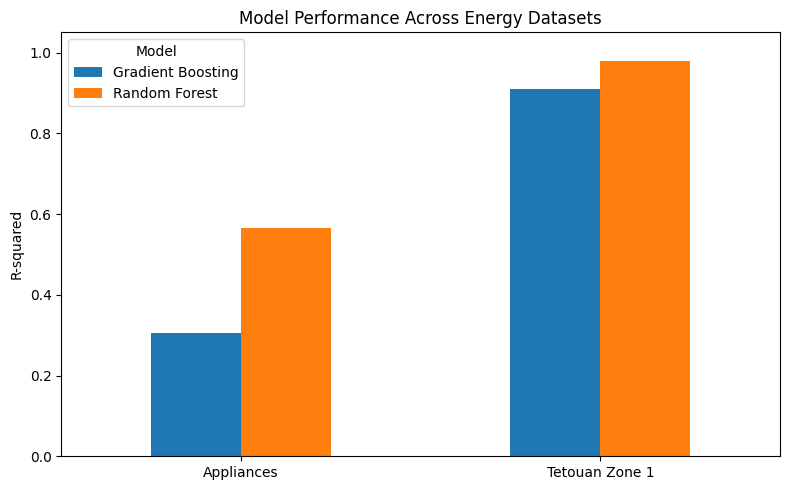

In [29]:
import matplotlib.pyplot as plt

#prepare the R-squared results for plotting
r2_plot = pd.DataFrame({
    'Dataset': [
        'Appliances',
        'Appliances',
        'Tetouan Zone 1',
        'Tetouan Zone 1'
    ],
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R-squared': [
        rf1_r2,
        gb1_r2,
        rf2_r2,
        gb2_r2
    ]
})

#create the grouped bar chart
r2_pivot = r2_plot.pivot(
    index='Dataset',
    columns='Model',
    values='R-squared'
)

ax = r2_pivot.plot(kind='bar', figsize=(8, 5))

ax.set_title('Model Performance Across Energy Datasets')
ax.set_ylabel('R-squared')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
ax.legend(title='Model')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(
    'model_r2_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

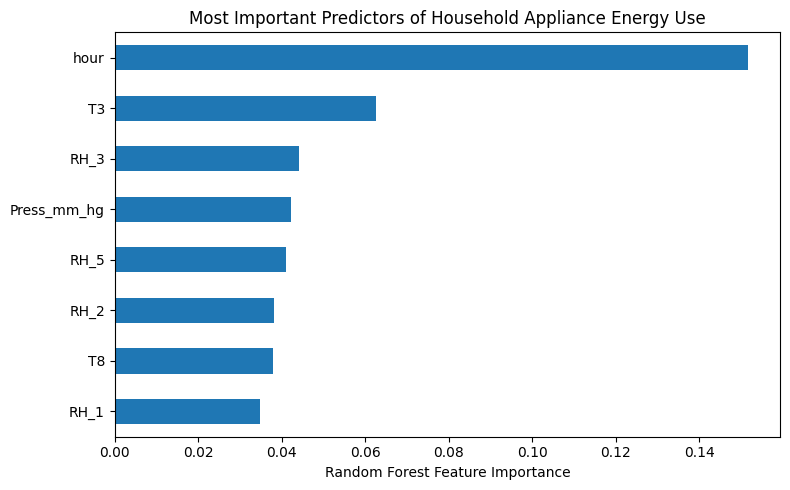

In [30]:
#Top feature importance for dataset 1
top_features1 = importance1.head(8).sort_values(
    by='Importance',
    ascending=True
)

ax = top_features1.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8, 5),
    legend=False
)

ax.set_title('Most Important Predictors of Household Appliance Energy Use')
ax.set_xlabel('Random Forest Feature Importance')
ax.set_ylabel('')

plt.tight_layout()

plt.savefig(
    'dataset1_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [31]:
import os

print("Current folder:", os.getcwd())
print(os.listdir())

Current folder: /content
['.config', 'dataset1_feature_importance.png', 'model_r2_comparison.png', 'sample_data']


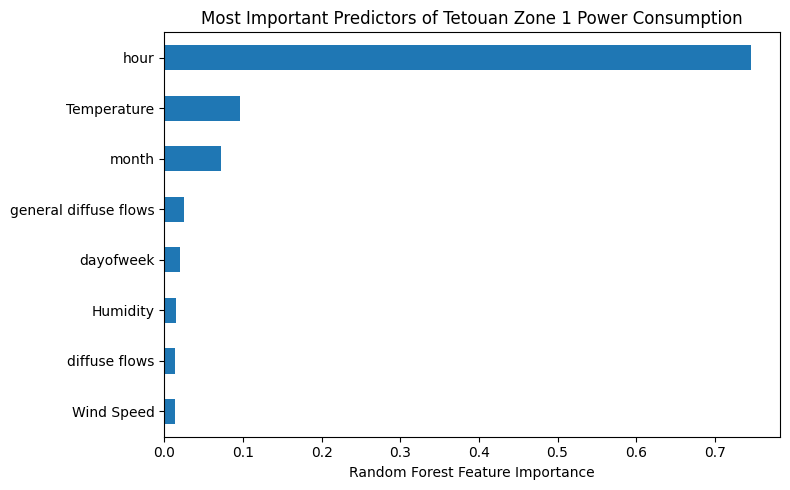

In [32]:
top_features2 = importance2.sort_values(
    by='Importance',
    ascending=True
)

ax = top_features2.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8, 5),
    legend=False
)

ax.set_title('Most Important Predictors of Tetouan Zone 1 Power Consumption')
ax.set_xlabel('Random Forest Feature Importance')
ax.set_ylabel('')

plt.tight_layout()

plt.savefig(
    'dataset2_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()